# Predikce vývoje ceny ropy pomocí strojového učení

**Seminární práce — KIUSU**

Vybral jsem si data o ceně ropy Brent a zkusil na nich metody strojového učení ze
scikit-learn. Zajímalo mě, jak přesný bude model, který má k dispozici
jenom historii ceny a žádné jiné parametry.

Řeším nad stejnými daty dvě úlohy:

1. Regrese, tedy odhad ceny na následující obchodní den.
2. Klasifikace, tedy zda cena zítra půjde nahoru, nebo dolů.

Postup je následující: získání dat, tvorba příznaků, popis, testování modelů, úprava hyperparametrů a vyhodnocení.


## 1. Popis datasetu

Data jsou denní ceny ropy Brent v dolarech za barel. Brent je jeden z hlavních
cenových ukazatelů.

Data jsem získal přes knihovnu
[`pandas-datareader`] ze zdroje FRED
(Federal Reserve Bank of St. Louis), série se nazývá `DCOILBRENTEU`.

Struktura je jednoduchá, jsou k dispozici pouze dva sloupce:

- `Date` — datum obchodního dne,
- `Price` — cena Brentu v USD za barel.

Časově se jedná o období mezi roky 1987 až 2026, což je zhruba 10 000 obchodních dní.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

os.environ["PYTHONWARNINGS"] = "ignore::RuntimeWarning"
np.seterr(all="ignore")
warnings.filterwarnings("ignore", category=RuntimeWarning)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 4.5)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
import pandas_datareader.data as web
import datetime as dt

raw = web.DataReader("DCOILBRENTEU", "fred",
                     dt.datetime(1987, 1, 1), dt.datetime(2026, 7, 1))
df = (raw.rename(columns={"DCOILBRENTEU": "Price"})
         .reset_index().rename(columns={"DATE": "Date"}))
df = df.sort_values("Date").dropna().reset_index(drop=True)

print("Tvar dat:", df.shape)
print("Rozsah:", df["Date"].min().date(), "->", df["Date"].max().date())
df.head()

Tvar dat: (9924, 2)
Rozsah: 1987-05-20 -> 2026-07-01


,Date,Price
0,1987-05-20,18.6300
1,1987-05-21,18.4500
2,1987-05-22,18.5500
3,1987-05-25,18.6000
4,1987-05-26,18.6300


In [3]:
# Základní popisné statistiky ceny
df["Price"].describe()

count   9924.0000
mean      51.2805
std       32.7702
min        9.1000
25%       19.5800
50%       46.3100
75%       74.8825
max      143.9500
Name: Price, dtype: float64

### Vývoj ceny v čase

Na grafu je zřetelné, co by se u ceny ropy dalo očekávat: dlouhý trend, občas hodně prudký
propad (2008 - celosvětová krize, pak 2020 pandemie) a v poslední době prudký nárůst kvůli válce na Ukrajině.
Řada je volatilní, průměrná
úroveň ceny se v čase pohybuje o desítky dolarů.


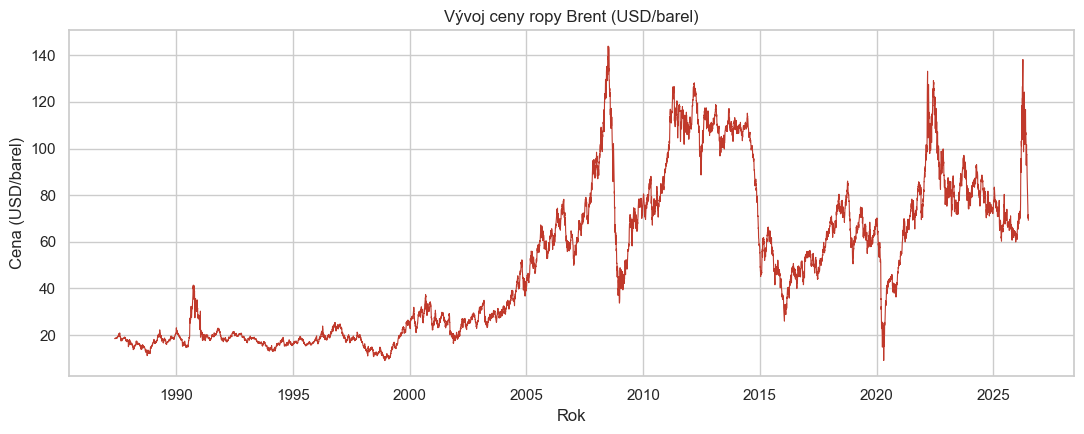

In [4]:
fig, ax = plt.subplots()
ax.plot(df["Date"], df["Price"], lw=0.8, color="#c0392b")
ax.set_title("Vývoj ceny ropy Brent (USD/barel)")
ax.set_xlabel("Rok"); ax.set_ylabel("Cena (USD/barel)")
plt.tight_layout(); plt.show()

### Denní výnosy

Pro modely se místo absolutní ceny často používá denní výnos, tedy procentuální
změna.


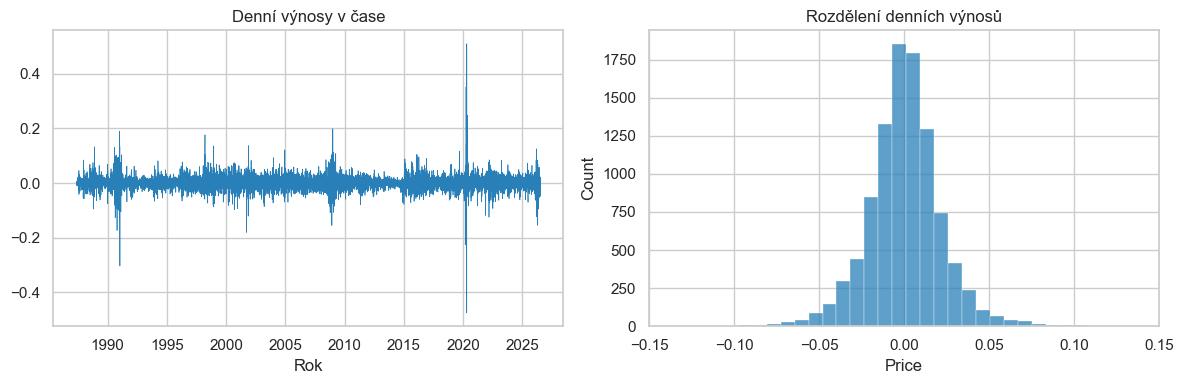

Průměrný denní výnos: 0.00045


In [5]:
returns = df["Price"].pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df["Date"].iloc[1:], returns, lw=0.5, color="#2980b9")
axes[0].set_title("Denní výnosy v čase"); axes[0].set_xlabel("Rok")
sns.histplot(x=returns, bins=120, ax=axes[1], color="#2980b9")
axes[1].set_title("Rozdělení denních výnosů"); axes[1].set_xlim(-0.15, 0.15)
plt.tight_layout(); plt.show()

print(f"Průměrný denní výnos: {returns.mean():.5f}")

## 2. Feature engineering

Z jednoho sloupce `Price` je potřeba vytvořit více příznaků. Držel jsem se pravidla, že
model smí v den $t$ vidět pouze to, co je do dne $t$ známé, a předpovídá den
$t+1$. Při zahrnutí budoucnosti do příznaků by vznikl data leakage a
výsledky by byly irelevantní.

Jaké příznaky jsem nakonec vytvořil:

| Skupina | Příznaky | Proč |
|---|---|---|
| Aktuální cena | `price` | zítřejší cena bývá obvykle blízko té současné |
| Zpoždění (*lags*) | `lag_1 … lag_10` | krátká historie, řada je silně autokorelovaná |
| Výnosy | `return_1`, `ret_lag_2 … ret_lag_10` | momentum |
| Klouzavé průměry | `roll_mean_5/10/20`, `ratio_mean_*` | trend a kde se nachází cena vůči svému průměru |
| Volatilita | `roll_std_5/10` | kolísavost |
| Kalendář | `dow`, `month` | test pro sezónnost |

Cíle jsou dva:

- `y_reg = price(t+1)` pro regresi,
- `y_clf = 1` když `price(t+1) > price(t)`, jinak `0`, pro klasifikaci směru.


In [6]:
def make_features(data: pd.DataFrame) -> pd.DataFrame:
    feature_df = pd.DataFrame({"Date": data["Date"].values})
    price = data["Price"].astype(float).reset_index(drop=True)
    feature_df["price"] = price

    # Zpožděné ceny (lags)
    for lag in [1, 2, 3, 5, 10]:
        feature_df[f"lag_{lag}"] = price.shift(lag)

    # Výnosy a jejich zpoždění (momentum)
    daily_returns = price.pct_change()
    feature_df["return_1"] = daily_returns
    for lag in [2, 3, 5, 10]:
        feature_df[f"ret_lag_{lag}"] = daily_returns.shift(lag)

    # Klouzavé průměry a poměr ceny k průměru (trend)
    for window in [5, 10, 20]:
        feature_df[f"roll_mean_{window}"] = price.rolling(window).mean()
        feature_df[f"ratio_mean_{window}"] = price / feature_df[f"roll_mean_{window}"]

    # Volatilita
    for window in [5, 10]:
        feature_df[f"roll_std_{window}"] = daily_returns.rolling(window).std()

    # Sezónnost
    feature_df["dow"] = data["Date"].dt.dayofweek.values
    feature_df["month"] = data["Date"].dt.month.values

    # Cíle
    feature_df["y_reg"] = price.shift(-1)
    feature_df["y_clf"] = (price.shift(-1) > price).astype(int)
    return feature_df

features = make_features(df).dropna().reset_index(drop=True)
feature_cols = [c for c in features.columns if c not in ["Date", "y_reg", "y_clf"]]
print(f"Počet příznaků: {len(feature_cols)}")
print(f"Počet vzorků po dropna: {len(features)}")
features[feature_cols].head()

Počet příznaků: 21
Počet vzorků po dropna: 9904


,price,lag_1,lag_2,lag_3,lag_5,lag_10,return_1,ret_lag_2,ret_lag_3,ret_lag_5,...,roll_mean_5,ratio_mean_5,roll_mean_10,ratio_mean_10,roll_mean_20,ratio_mean_20,roll_std_5,roll_std_10,dow,month
0,19.0300,18.9000,18.7800,18.6800,18.7800,18.6800,0.0069,0.0054,-0.0053,0.0016,...,18.8340,1.0104,18.7880,1.0129,18.6925,1.0181,0.0052,0.0048,2,6
1,19.0500,19.0300,18.9000,18.7800,18.7800,18.7500,0.0011,0.0064,0.0054,0.0000,...,18.8880,1.0086,18.8180,1.0123,18.7135,1.0180,0.0051,0.0047,3,6
2,19.0500,19.0500,19.0300,18.9000,18.6800,18.7800,0.0000,0.0069,0.0064,-0.0053,...,18.9620,1.0046,18.8450,1.0109,18.7435,1.0164,0.0032,0.0048,4,6
3,19.1000,19.0500,19.0500,19.0300,18.7800,18.6500,0.0026,0.0011,0.0069,0.0054,...,19.0260,1.0039,18.8900,1.0111,18.7710,1.0175,0.0031,0.0038,0,6
4,18.9000,19.1000,19.0500,19.0500,18.9000,18.7500,-0.0105,0.0000,0.0011,0.0064,...,19.0260,0.9934,18.9050,0.9997,18.7860,1.0061,0.0064,0.0054,1,6


### Korelace příznaků

Heatmapa potvrdila, že všechny cenové příznaky jsou mezi sebou skoro dokonale korelované, protože je to pořád
skoro ta samá cena, jen posunutá o pár dní. To je vícenásobná korelace. Proto dále používám Ridge a Lasso — regularizace si s tím poradí lépe než obyčejná
lineární regrese. Výnosy a volatilita se naopak tváří jako samostatné informace.


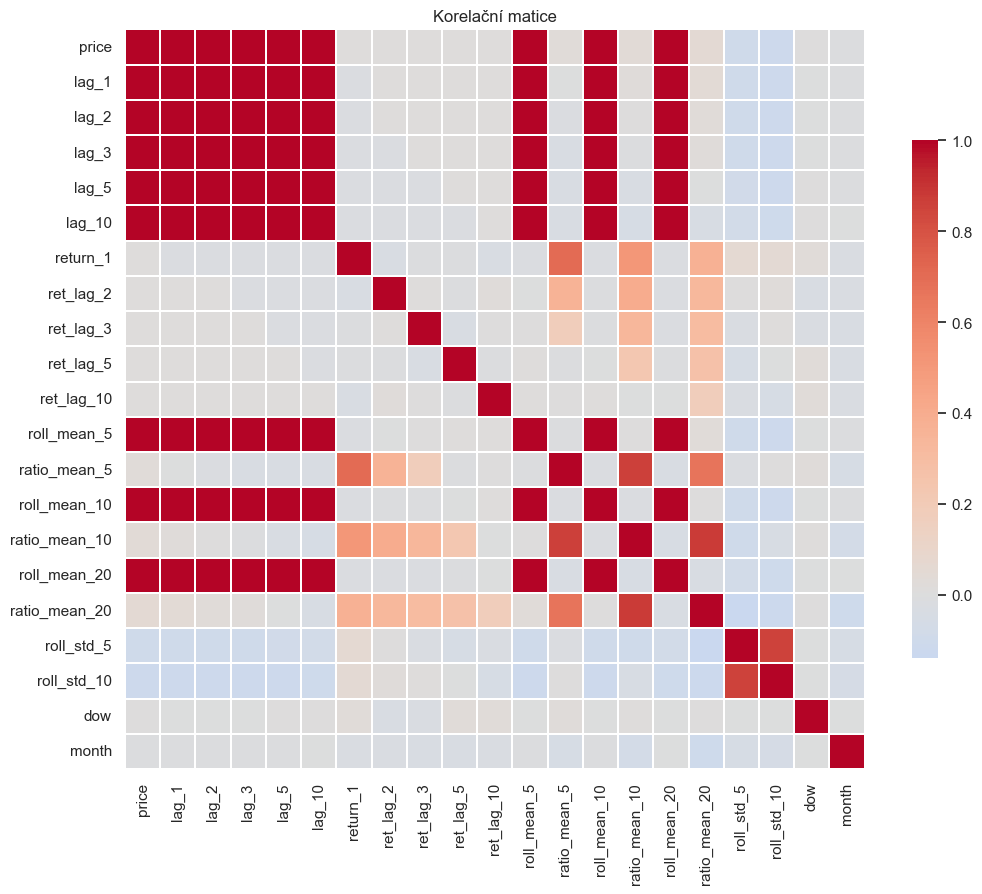

In [7]:
corr_matrix = features[feature_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True,
            linewidths=0.3, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Korelační matice")
plt.tight_layout(); plt.show()

## 3. Metodika validace pro časové řady

U časové řady se nesmí míchat data náhodně (`shuffle=True`).
Poté by se model trénoval na dnech, které jsou v testovací množině v
budoucnosti, a v praxi by je nikdy neměl k dispozici.

Postupoval jsem následovně:

- Chronologický split, starších 80 % dat na trénování, novějších 20 % na testování.
- Křížová validace přes `TimeSeriesSplit`, kde každý fold trénuje na minulosti a
  validuje na úseku hned za ní. Trénovací množina se postupně rozšiřuje.

In [8]:
from sklearn.model_selection import TimeSeriesSplit

X = features[feature_cols].copy()
y_reg = features["y_reg"].copy()
y_clf = features["y_clf"].copy()

n_samples = len(features)
split_idx = int(n_samples * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_reg_train, y_reg_test = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]
y_clf_train, y_clf_test = y_clf.iloc[:split_idx], y_clf.iloc[split_idx:]
dates_test = features["Date"].iloc[split_idx:]

ts_split = TimeSeriesSplit(n_splits=5)

print(f"Trénink: {len(X_train)} vzorků  ({features['Date'].iloc[0].date()} -> {features['Date'].iloc[split_idx-1].date()})")
print(f"Test:    {len(X_test)} vzorků  ({features['Date'].iloc[split_idx].date()} -> {features['Date'].iloc[-1].date()})")
print(f"Rozdělení tříd (směr) na tréninku: {dict(y_clf_train.value_counts())}")

Trénink: 7923 vzorků  (1987-06-17 -> 2018-08-31)
Test:    1981 vzorků  (2018-09-03 -> 2026-06-30)
Rozdělení tříd (směr) na tréninku: {1: np.int64(3972), 0: np.int64(3951)}


## 4. Regrese — predikce ceny příštího dne

### 4.1 Baseline modely

Než začneme modely upravovat, potřebujeme nějaký základ jako referenci, který budou muset modely porazit:

- Naivní model, který řekne "zítra bude stejná cena jako dnes". U takhle
  perzistentní řady se jeví jako dobrá volba.
- Lineární regrese bez regularizace.

Měřím $R^2$, MAE (průměrná absolutní chyba) a RMSE. RMSE mi přijde nejčitelnější,
protože vychází přímo v dolarech za barel.


In [9]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

reg_results = {}

def evaluate_regression(name, y_pred):
    reg_results[name] = {
        "R2": r2_score(y_reg_test, y_pred),
        "MAE": mean_absolute_error(y_reg_test, y_pred),
        "RMSE": rmse(y_reg_test, y_pred),
    }
    metrics = reg_results[name]
    print(f"{name:28s}  R2={metrics['R2']:.5f}  MAE={metrics['MAE']:.4f}  RMSE={metrics['RMSE']:.4f}")

# baseline model zitra = dnes
evaluate_regression("Naivní (cena dnes)", X_test["price"].values)

Naivní (cena dnes)            R2=0.98814  MAE=1.3789  RMSE=2.0947


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lin_reg = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
lin_reg.fit(X_train, y_reg_train)
evaluate_regression("Lineární regrese", lin_reg.predict(X_test))

Lineární regrese              R2=0.98815  MAE=1.3767  RMSE=2.0940


### 4.2 Pokročilejší modely a hyperparametry

Teď modely, u kterých můžeme upravit parametry. Hyperparametry hledám přes `GridSearchCV`
s `TimeSeriesSplit` a skóruju podle záporné RMSE
(`neg_root_mean_squared_error`).

Proč zrovna tyhle parametry:

- **Ridge a Lasso** — `alpha` říká, jak silná je regularizace. Vzhledem k tomu,
  jak jsou cenové příznaky silně korelované (viz heatmapa), to dává smysl.
  Malá `alpha` se chová skoro jako obyčejná regrese, velká koeficienty smrskne
  k nule. Lasso navíc umí některé příznaky vyhodit úplně.
- **KNN** — `n_neighbors` je klasický bias-variance kompromis, málo sousedů se
  přeučí, hodně sousedů všechno rozmaže. `weights="distance"` dává bližším
  sousedům větší váhu. KNN počítá vzdálenosti.
- **Random Forest** — `n_estimators` (více stromů, stabilnější výsledek),
  `max_depth` a `min_samples_leaf` hlídají, aby se stromy nepřeučily.
- **Gradient Boosting** — `learning_rate` a `n_estimators` jdou proti sobě (menší
  krok, víc iterací) a `max_depth` určuje, jak složité jsou jednotlivé stromy.


In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

def tune_regression(name, estimator, param_grid, scale=True):
    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    pipeline = Pipeline(steps)
    prefixed_grid = {f"model__{param}": values for param, values in param_grid.items()}
    grid_search = GridSearchCV(pipeline, prefixed_grid, cv=ts_split,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid_search.fit(X_train, y_reg_train)
    evaluate_regression(name, grid_search.predict(X_test))
    print(f"    nejlepší parametry: {grid_search.best_params_}")
    return grid_search

grid_ridge = tune_regression("Ridge", Ridge(random_state=RANDOM_STATE),
                             {"alpha": [0.1, 1, 10, 50, 100, 300]})
grid_lasso = tune_regression("Lasso", Lasso(random_state=RANDOM_STATE, max_iter=5000),
                             {"alpha": [0.001, 0.01, 0.1, 1, 5]})
grid_knn = tune_regression("KNN", KNeighborsRegressor(),
                           {"n_neighbors": [5, 10, 20, 40], "weights": ["uniform", "distance"]})

Ridge                         R2=0.98817  MAE=1.3778  RMSE=2.0926
    nejlepší parametry: {'model__alpha': 0.1}
Lasso                         R2=0.98819  MAE=1.3780  RMSE=2.0909
    nejlepší parametry: {'model__alpha': 0.001}
KNN                           R2=0.89486  MAE=4.0310  RMSE=6.2381
    nejlepší parametry: {'model__n_neighbors': 5, 'model__weights': 'distance'}


In [12]:
grid_rf = tune_regression("Random Forest", RandomForestRegressor(random_state=RANDOM_STATE),
                          {"n_estimators": [200], "max_depth": [None, 10, 20],
                           "min_samples_leaf": [1, 5]}, scale=False)
grid_gb = tune_regression("Gradient Boosting", GradientBoostingRegressor(random_state=RANDOM_STATE),
                          {"n_estimators": [200], "learning_rate": [0.05, 0.1],
                           "max_depth": [2, 3]}, scale=False)

Random Forest                 R2=0.98746  MAE=1.4462  RMSE=2.1540
    nejlepší parametry: {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Gradient Boosting             R2=0.98686  MAE=1.4902  RMSE=2.2053
    nejlepší parametry: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}


### 4.3 Porovnání regresních modelů

Seřazeno podle RMSE, nižší je lepší.


In [13]:
reg_results_df = pd.DataFrame(reg_results).T.sort_values("RMSE")
reg_results_df

,R2,MAE,RMSE
Lasso,0.9882,1.3780,2.0909
Ridge,0.9882,1.3778,2.0926
Lineární regrese,0.9882,1.3767,2.0940
Naivní (cena dnes),0.9881,1.3789,2.0947
Random Forest,0.9875,1.4462,2.1540
Gradient Boosting,0.9869,1.4902,2.2053
KNN,0.8949,4.0310,6.2381


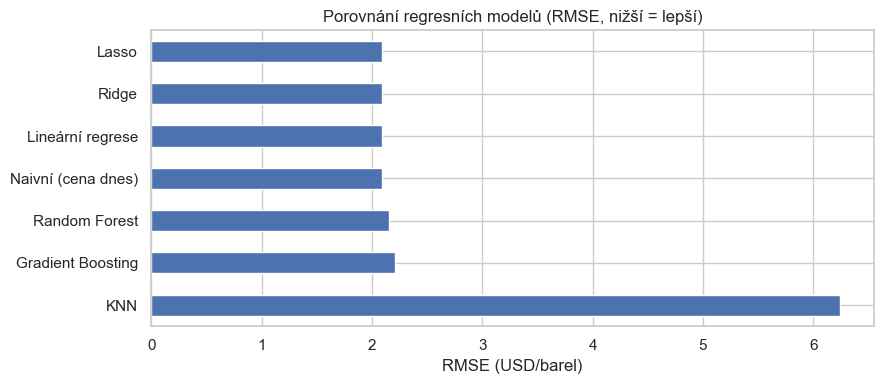

In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
reg_results_df["RMSE"].plot(kind="barh", ax=ax)
ax.set_title("Porovnání regresních modelů (RMSE, nižší = lepší)")
ax.set_xlabel("RMSE (USD/barel)"); ax.invert_yaxis()
plt.tight_layout(); plt.show()


Zde vidíme predikci nejlepšího modelu proti skutečnosti na testovacím období.
Body leží skoro přesně na diagonále, je to zřejmě zejména tím, že
zítřejší cena je hodně blízká té dnešní. Přidal jsem klasifikaci směru.


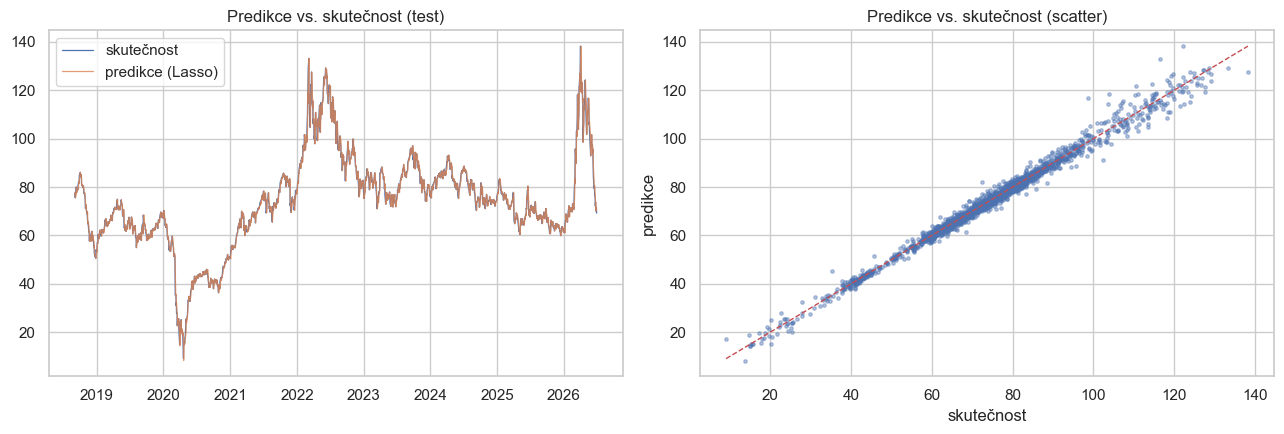

Nejlepší regresní model: Lasso


In [15]:
best_reg_name = reg_results_df.index[0]
best_reg_model = {"Ridge": grid_ridge, "Lasso": grid_lasso, "KNN": grid_knn,
                  "Random Forest": grid_rf, "Gradient Boosting": grid_gb}.get(best_reg_name)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
if best_reg_model is not None:
    y_pred_reg_best = best_reg_model.predict(X_test)
else:
    y_pred_reg_best = X_test["price"].values  # baseline
axes[0].plot(dates_test, y_reg_test.values, label="skutečnost", lw=0.9)
axes[0].plot(dates_test, y_pred_reg_best, label=f"predikce ({best_reg_name})", lw=0.9, alpha=0.8)
axes[0].set_title("Predikce vs. skutečnost (test)"); axes[0].legend()
axes[1].scatter(y_reg_test, y_pred_reg_best, s=6, alpha=0.4)
axis_limits = [y_reg_test.min(), y_reg_test.max()]
axes[1].plot(axis_limits, axis_limits, "r--", lw=1)
axes[1].set_xlabel("skutečnost"); axes[1].set_ylabel("predikce")
axes[1].set_title("Predikce vs. skutečnost (scatter)")
plt.tight_layout(); plt.show()
print("Nejlepší regresní model:", best_reg_name)

### 4.4 Důležitost příznaků

Stromové modely umí vrátit `feature_importances_`. Nepřekvapivě vede aktuální
cena, ostatní je zanedbatelné.


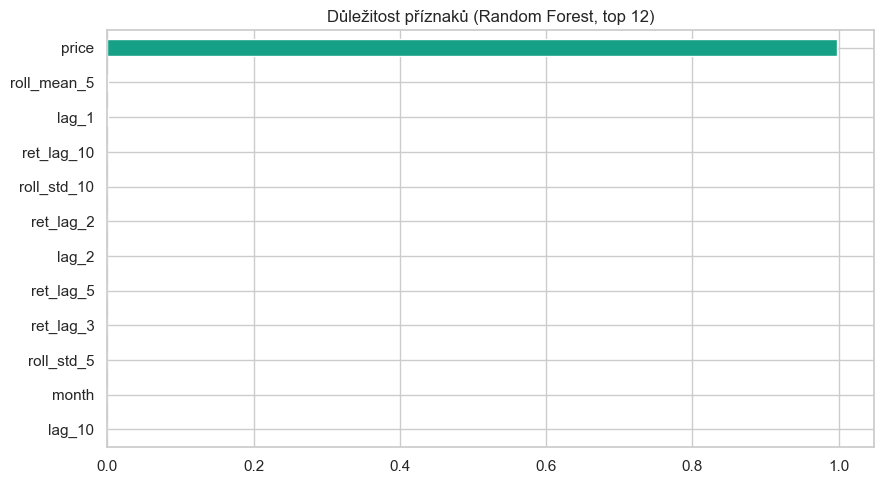

In [16]:
rf_model = grid_rf.best_estimator_.named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
importances.head(12).iloc[::-1].plot(kind="barh", ax=ax, color="#16a085")
ax.set_title("Důležitost příznaků (Random Forest, top 12)")
plt.tight_layout(); plt.show()

## 5. Klasifikace — predikce směru pohybu ceny
Zde je cílem určit zda cena zítra vzroste (1), nebo klesne (0). Tady
už perzistence řady nepomůže, protože znalost dnešní ceny sama o sobě neříká nic
o tom, kterým směrem půjde v budoucnu.

### 5.1 Baseline

- Majoritní třída přes `DummyClassifier`, tedy hádat pravděpodobnější směr.
- Logistická regrese


In [17]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

clf_results = {}

def evaluate_classification(name, model, y_proba=None):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_clf_test, y_pred)
    f1 = f1_score(y_clf_test, y_pred)
    auc = np.nan
    if y_proba is not None:
        auc = roc_auc_score(y_clf_test, y_proba)
    clf_results[name] = {"Accuracy": accuracy, "F1": f1, "ROC_AUC": auc}
    print(f"{name:28s}  Acc={accuracy:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    return y_pred

dummy_clf = DummyClassifier(strategy="most_frequent").fit(X_train, y_clf_train)
evaluate_classification("Majoritní třída", dummy_clf)

logreg = Pipeline([("scaler", StandardScaler()),
                   ("model", LogisticRegression(max_iter=1000,
                                                class_weight="balanced",
                                                random_state=RANDOM_STATE))])
logreg.fit(X_train, y_clf_train)
evaluate_classification("Logistická regrese", logreg, y_proba=logreg.predict_proba(X_test)[:, 1])

Majoritní třída               Acc=0.5255  F1=0.6889  AUC=nan
Logistická regrese            Acc=0.5164  F1=0.5589  AUC=0.5179


array([1, 1, 1, ..., 0, 0, 0], shape=(1981,))

### 5.2 Pokročilejší klasifikátory a hyperparametry

Parametry:

- **Logistická regrese** — `C` je převrácená hodnota síly regularizace, takže
  malé `C` znamená silnou regularizaci. Měním ho kvůli vícenásobné korelaci.
- **SVC** — `C` je kompromis mezi širokým marginem a tolerancí chyb, `kernel`
  určuje, zda hledáme lineární nebo zakřivenou hranici, a `gamma` u RBF říká,
  jak daleko dosahuje vliv jednoho bodu.
- **Random Forest a Gradient Boosting** — stejná logika jako u regrese, hloubka a
  počet stromů upravuje složitost.

Zjišťujeme `accuracy`, pořád s `TimeSeriesSplit`.


In [18]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

def tune_classification(name, estimator, param_grid, scale=True, use_proba=True):
    steps = []
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", estimator))
    pipeline = Pipeline(steps)
    prefixed_grid = {f"model__{param}": values for param, values in param_grid.items()}
    grid_search = GridSearchCV(pipeline, prefixed_grid, cv=ts_split, scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train, y_clf_train)
    y_proba = None
    if use_proba:
        if hasattr(grid_search.best_estimator_, "predict_proba"):
            y_proba = grid_search.predict_proba(X_test)[:, 1]
        elif hasattr(grid_search.best_estimator_, "decision_function"):
            y_proba = grid_search.decision_function(X_test)
    evaluate_classification(name, grid_search, y_proba=y_proba)
    print(f"    nejlepší parametry: {grid_search.best_params_}")
    return grid_search

grid_logreg = tune_classification("Logistická regrese (laděná)",
                                  LogisticRegression(max_iter=2000, class_weight="balanced",
                                                     random_state=RANDOM_STATE),
                                  {"C": [0.001, 0.01, 0.1, 1, 10]})
grid_svc = tune_classification("SVC",
                               SVC(class_weight="balanced", random_state=RANDOM_STATE),
                               {"C": [0.1, 1, 10], "kernel": ["rbf"], "gamma": ["scale"]})

Logistická regrese (laděná)   Acc=0.5315  F1=0.5797  AUC=0.5320
    nejlepší parametry: {'model__C': 0.01}
SVC                           Acc=0.4982  F1=0.5749  AUC=0.4957
    nejlepší parametry: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


In [19]:
grid_rf_clf = tune_classification("Random Forest",
                                  RandomForestClassifier(class_weight="balanced",
                                                         random_state=RANDOM_STATE),
                                  {"n_estimators": [300], "max_depth": [3, 5, 10],
                                   "min_samples_leaf": [10, 50]}, scale=False)
grid_gb_clf = tune_classification("Gradient Boosting",
                                  GradientBoostingClassifier(random_state=RANDOM_STATE),
                                  {"n_estimators": [200], "learning_rate": [0.05, 0.1],
                                   "max_depth": [2, 3]}, scale=False)

Random Forest                 Acc=0.5048  F1=0.5680  AUC=0.4972
    nejlepší parametry: {'model__max_depth': 10, 'model__min_samples_leaf': 50, 'model__n_estimators': 300}
Gradient Boosting             Acc=0.5114  F1=0.5728  AUC=0.5156
    nejlepší parametry: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}


### 5.3 Porovnání klasifikátorů

Laťka, kterou je potřeba překonat, je podíl majoritní třídy v testu (a tomu
odpovídající accuracy majoritního modelu).


In [20]:
clf_results_df = pd.DataFrame(clf_results).T.sort_values("Accuracy", ascending=False)
majority_share = y_clf_test.value_counts(normalize=True).max()
print(f"Podíl majoritní třídy v testu: {majority_share:.4f}")
clf_results_df

Podíl majoritní třídy v testu: 0.5255


,Accuracy,F1,ROC_AUC
Logistická regrese (laděná),0.5315,0.5797,0.5320
Majoritní třída,0.5255,0.6889,NaN
Logistická regrese,0.5164,0.5589,0.5179
Gradient Boosting,0.5114,0.5728,0.5156
Random Forest,0.5048,0.5680,0.4972
SVC,0.4982,0.5749,0.4957


### 5.4 Matice záměn nejlepšího klasifikátoru

Použiji model s nejvyšší accuracy. Z matice záměn je lépe vidět, kde model chybuje,
než ze samotného čísla. U predikce směru se často stane, že model jednu třídu
předpovídá mnohem častěji než druhou, i když jsou téměř vyrovnané.


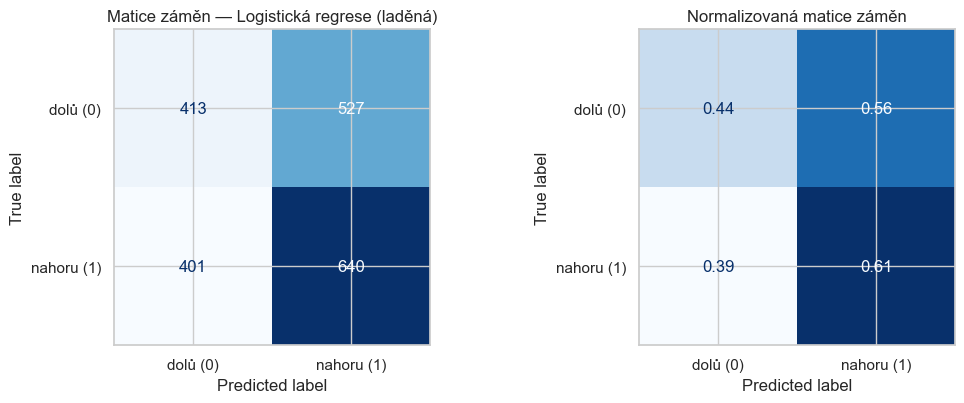

              precision    recall  f1-score   support

    dolů (0)       0.51      0.44      0.47       940
  nahoru (1)       0.55      0.61      0.58      1041

    accuracy                           0.53      1981
   macro avg       0.53      0.53      0.53      1981
weighted avg       0.53      0.53      0.53      1981



In [21]:
best_clf_name = clf_results_df.index[0]
best_clf_model = {"Logistická regrese (laděná)": grid_logreg, "SVC": grid_svc,
                  "Random Forest": grid_rf_clf, "Gradient Boosting": grid_gb_clf,
                  "Logistická regrese": logreg}.get(best_clf_name, grid_logreg)

y_pred_clf_best = best_clf_model.predict(X_test)
cm = confusion_matrix(y_clf_test, y_pred_clf_best)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay(cm, display_labels=["dolů (0)", "nahoru (1)"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Matice záměn — {best_clf_name}")
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_pred_clf_best, display_labels=["dolů (0)", "nahoru (1)"],
    normalize="true", cmap="Blues", colorbar=False, ax=axes[1])
axes[1].set_title("Normalizovaná matice záměn")
plt.tight_layout(); plt.show()

print(classification_report(y_clf_test, y_pred_clf_best,
                            target_names=["dolů (0)", "nahoru (1)"]))

## 6. Studie: jak dosáhnout co nejlepších výsledků

V této části zkouším různé úpravy modelů a porovnávám, co se stane. Cílem je pochopit, na čem daný výsledek závisí.


### 6.1 Vliv sady příznaků

Porovnávám tři sady příznaků na jednom pevném modelu (Ridge pro regresi, laděná
logistická regrese pro klasifikaci): nejdřív jen zpožděné ceny, pak k tomu výnosy
a nakonec ještě klouzavé průměry s volatilitou. Zajímá mě, kolik toho odvozené
příznaky vlastně přidají.


In [22]:
cols_lag = [c for c in feature_cols if c.startswith("lag_") or c == "price"]
cols_lag_returns = cols_lag + [c for c in feature_cols if c.startswith("return") or c.startswith("ret_lag")]
cols_all = feature_cols

def rmse_for_features(cols):
    grid_search = GridSearchCV(Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
                               {"model__alpha": [0.1, 1, 10, 100]}, cv=ts_split,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid_search.fit(X_train[cols], y_reg_train)
    return rmse(y_reg_test, grid_search.predict(X_test[cols]))

def accuracy_for_features(cols):
    grid_search = GridSearchCV(Pipeline([("scaler", StandardScaler()),
                                         ("model", LogisticRegression(max_iter=2000,
                                                    class_weight="balanced"))]),
                               {"model__C": [0.01, 0.1, 1, 10]}, cv=ts_split,
                               scoring="accuracy", n_jobs=-1)
    grid_search.fit(X_train[cols], y_clf_train)
    return accuracy_score(y_clf_test, grid_search.predict(X_test[cols]))

feature_set_rows = []
for label, cols in [("jen ceny/lagy", cols_lag),
                    ("+ výnosy", cols_lag_returns),
                    ("+ klouzavé prům./volatilita (vše)", cols_all)]:
    feature_set_rows.append({"sada příznaků": label, "počet": len(cols),
                             "RMSE (regrese)": rmse_for_features(cols),
                             "Accuracy (klasif.)": accuracy_for_features(cols)})
pd.DataFrame(feature_set_rows).set_index("sada příznaků")

,počet,RMSE (regrese),Accuracy (klasif.)
sada příznaků,,,
jen ceny/lagy,6,2.0950,0.4912
+ výnosy,11,2.0936,0.5038
+ klouzavé prům./volatilita (vše),21,2.0926,0.5315


### 6.2 Vliv škálování (na KNN)

KNN pracuje se vzdálenostmi, takže by na škálování mělo být citlivé. Očekával jsem,
že škálovaná verze bude horší.

Bez škálování dominuje ve vzdálenosti absolutní cena (`price`, `lag_*`), protože
má největší hodnotu. Z předchozích zjištění víme, že se jedná o nejdůležitější příznak. Po
naškálování dostanou všechny příznaky stejnou váhu, význam ceny se vytratí a přesnost upadá.

In [23]:
from sklearn.metrics import mean_squared_error

knn_unscaled = KNeighborsRegressor(n_neighbors=20, weights="distance").fit(X_train, y_reg_train)
knn_scaled = Pipeline([("scaler", StandardScaler()),
                        ("model", KNeighborsRegressor(n_neighbors=20, weights="distance"))]).fit(X_train, y_reg_train)
print(f"KNN bez škálování   RMSE = {rmse(y_reg_test, knn_unscaled.predict(X_test)):.4f}")
print(f"KNN se škálováním   RMSE = {rmse(y_reg_test, knn_scaled.predict(X_test)):.4f}")

KNN bez škálování   RMSE = 2.7975
KNN se škálováním   RMSE = 5.6694


### 6.3 Vliv velikosti trénovacích dat

Tady se dívám, jak se mění chyba regrese podle toho, kolik dám modelu trénovacích dat k dispozici.
U této časové řady více trénovacích dat nezlepší výsledný model. Data např. z 90.let reflektují úplně jinou situaci na trhu než v současnosti.


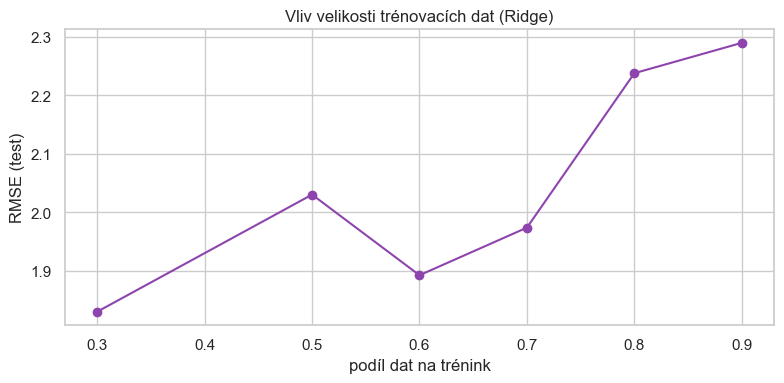

,podíl na trénink,test vzorků,RMSE
0,0.3000,6933,1.8303
1,0.5000,4952,2.0302
2,0.6000,3962,1.8926
3,0.7000,2972,1.9738
4,0.8000,1981,2.2374
5,0.9000,991,2.2893


In [24]:
train_size_rows = []
for train_frac in [0.3, 0.5, 0.6, 0.7, 0.8, 0.9]:
    split_idx = int(n_samples * train_frac)
    X_train_part, X_test_part = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train_part, y_test_part = y_reg.iloc[:split_idx], y_reg.iloc[split_idx:]
    ridge_pipeline = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train_part, y_train_part)
    train_size_rows.append({"podíl na trénink": train_frac, "test vzorků": len(X_test_part),
                            "RMSE": rmse(y_test_part, ridge_pipeline.predict(X_test_part))})
train_size_df = pd.DataFrame(train_size_rows)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_size_df["podíl na trénink"], train_size_df["RMSE"], "o-", color="#8e44ad")
ax.set_xlabel("podíl dat na trénink"); ax.set_ylabel("RMSE (test)")
ax.set_title("Vliv velikosti trénovacích dat (Ridge)")
plt.tight_layout(); plt.show()
train_size_df

### 6.4 Vliv hyperparametrů

Křivky ukazují bias-variance kompromis. Když je regularizace moc
slabá, model se přeučí, když je moc silná, tak se naučí málo, a optimum je
zhruba uprostřed.


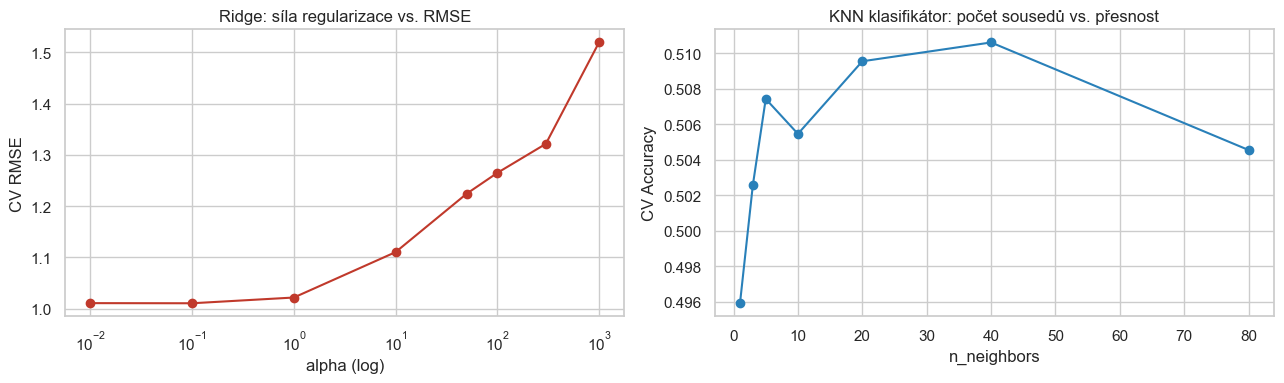

In [25]:
from sklearn.model_selection import cross_val_score

# Ridge: alpha vs RMSE
alphas = [0.01, 0.1, 1, 10, 50, 100, 300, 1000]
ridge_scores = []
for alpha in alphas:
    scores = cross_val_score(Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=alpha))]),
                             X_train, y_reg_train, cv=ts_split,
                             scoring="neg_root_mean_squared_error")
    ridge_scores.append(-scores.mean())

neighbor_counts = [1, 3, 5, 10, 20, 40, 80]
from sklearn.neighbors import KNeighborsClassifier
knn_scores = []
for k_neighbors in neighbor_counts:
    scores = cross_val_score(Pipeline([("scaler", StandardScaler()),
                                       ("model", KNeighborsClassifier(n_neighbors=k_neighbors))]),
                             X_train, y_clf_train, cv=ts_split, scoring="accuracy")
    knn_scores.append(scores.mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(alphas, ridge_scores, "o-", color="#c0392b")
axes[0].set_xscale("log"); axes[0].set_xlabel("alpha (log)")
axes[0].set_ylabel("CV RMSE"); axes[0].set_title("Ridge: síla regularizace vs. RMSE")
axes[1].plot(neighbor_counts, knn_scores, "o-", color="#2980b9")
axes[1].set_xlabel("n_neighbors"); axes[1].set_ylabel("CV Accuracy")
axes[1].set_title("KNN klasifikátor: počet sousedů vs. přesnost")
plt.tight_layout(); plt.show()

### 6.5 Vliv časového horizontu predikce

Zatím jsem vždy předpovídal pouze následující den. Napadlo mne, jestli to není zbytečné omezení, tak jsem zkusil predikovat delší časový horizont.


Delší horizont jsem provedl následujícími způsoby:

- **Přímý (direct)** — pro každý horizont *h* natrénuju vlastní model. 
  Příznaky zůstávají stejné, pořád jen to, co víme v den *t*, a
  chyba se nikde nesčítá.
- **Rekurzivní (recursive)** — pustím jednodenní model, jeho predikci vrátím zpět
  na vstup a spustím znovu. Znamená to dopočítávat lagy a klouzavé průměry z
  vlastních odhadů, takže se chyby nabalují.

Zkusil jsem *h* = 1, 5, 10, 20 a 60 obchodních dní, vždy oproti naivní baseline
"zítřek je dnešek".


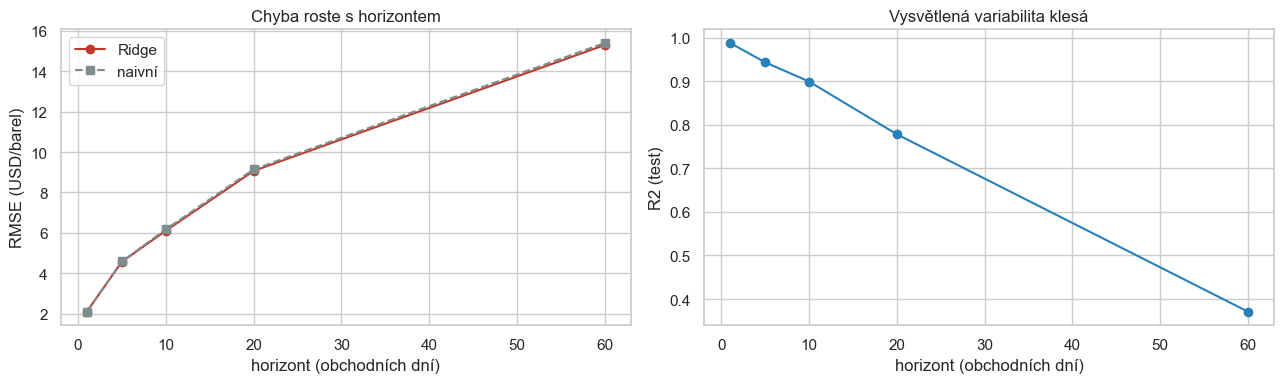

,RMSE model,RMSE naivní,R2 model,zlepšení vs. naivní (%)
horizont (dní),,,,
1,2.0925,2.0946,0.9882,0.1036
5,4.5712,4.5811,0.9436,0.2162
10,6.1042,6.1756,0.8994,1.1561
20,9.0663,9.1407,0.7783,0.8136
60,15.3044,15.4079,0.3708,0.6716


In [26]:
horizon_rows = []
for horizon in [1, 5, 10, 20, 60]:
    y_future = features["price"].shift(-horizon)
    mask = y_future.notna()
    X_horizon, y_horizon = X[mask], y_future[mask]
    split_idx = int(len(X_horizon) * 0.8)
    X_train_h, X_test_h = X_horizon.iloc[:split_idx], X_horizon.iloc[split_idx:]
    y_train_h, y_test_h = y_horizon.iloc[:split_idx], y_horizon.iloc[split_idx:]

    grid_horizon = GridSearchCV(Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
                                {"model__alpha": [0.1, 1, 10, 100]}, cv=ts_split,
                                scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid_horizon.fit(X_train_h, y_train_h)
    y_pred_h = grid_horizon.predict(X_test_h)
    y_naive_h = X_test_h["price"].values          # baseline

    horizon_rows.append({"horizont (dní)": horizon,
                         "RMSE model": rmse(y_test_h, y_pred_h),
                         "RMSE naivní": rmse(y_test_h, y_naive_h),
                         "R2 model": r2_score(y_test_h, y_pred_h),
                         "zlepšení vs. naivní (%)":
                             100 * (1 - rmse(y_test_h, y_pred_h) / rmse(y_test_h, y_naive_h))})

horizon_df = pd.DataFrame(horizon_rows).set_index("horizont (dní)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(horizon_df.index, horizon_df["RMSE model"], "o-", label="Ridge", color="#c0392b")
axes[0].plot(horizon_df.index, horizon_df["RMSE naivní"], "s--", label="naivní", color="#7f8c8d")
axes[0].set_xlabel("horizont (obchodních dní)"); axes[0].set_ylabel("RMSE (USD/barel)")
axes[0].set_title("Chyba roste s horizontem"); axes[0].legend()
axes[1].plot(horizon_df.index, horizon_df["R2 model"], "o-", color="#2980b9")
axes[1].set_xlabel("horizont (obchodních dní)"); axes[1].set_ylabel("R2 (test)")
axes[1].set_title("Vysvětlená variabilita klesá")
plt.tight_layout(); plt.show()

horizon_df

Nevysvětlená složka se přes dny sčítá podobně jako u náhodné procházky. $R^2$ mezitím
spadne z 0,988 na nějakých 0,37. To je podle mě to nejzajímavější zjištění celé
práce: vysoké $R^2$ u jednodenní predikce není zásluha modelu, ale zejména toho, že
cena se ze dne na den skoro nemění. Model přitom naivní baseline poráží na všech
horizontech jen o desetiny procenta.

Jednodenní horizont jsem zvolil proto, že bude mít nejmenší chybu a jde s ním srovnávat klasifikační úloha
(směr pohybu zítra). Prakticky ale delší horizonty moc smysl nedávají, od
zhruba 20 dní výše je odhad úrovně ceny skoro k nerozeznání od původní ceny.


### 6.6 Rolling (rekurzivní) predikce na 30 dní

V předchozí části jsem delší horizont řešil přímým modelem, tedy zvlášť natrénovaným
modelem pro každé *h*. Model měl přitom v každém kroku k dispozici skutečnou cenu ze
dne *t*. To ale neodpovídá tomu, jak by se predikce používala v praxi, kdy bych
skutečné ceny na měsíc dopředu k dispozici neměl.

Proto tady zkouším **rolling (rekurzivní) predikci**: model natrénuji jednou na
jednodenní úlohu a pak ho pouštím opakovaně tak, že jeho vlastní predikce vracím
zpátky na vstup. Skutečná data se použijí jen pro první krok, další kroky už
počítají lagy, výnosy, klouzavé průměry i volatilitu z odhadnutých cen. Chyba se
tím pádem přenáší do dalších kroků a nabaluje se.

Použil jsem Ridge (nejlepší model z části 4.3) a jako start jsem vzal první den
testovací množiny. Porovnávám tři varianty:

- **rolling** — 30 kroků dopředu jen z vlastních predikcí,
- **jednokroková predikce** — model dostane před každým krokem skutečnou cenu z
  předchozího dne (to, co dělal v celé kapitole 4),
- **naivní baseline** — celých 30 dní drží poslední známou skutečnou cenu.


In [27]:
ROLLING_HORIZON = 30

rolling_model = Pipeline([("scaler", StandardScaler()),
                          ("model", Ridge(alpha=grid_ridge.best_params_["model__alpha"]))])
rolling_split_idx = int(n_samples * 0.8)
rolling_model.fit(X.iloc[:rolling_split_idx], y_reg.iloc[:rolling_split_idx])


def rolling_forecast(model, start_pos, horizon=ROLLING_HORIZON):
    history = df.iloc[:start_pos + 1][["Date", "Price"]].copy()
    future = df.iloc[start_pos + 1:start_pos + 1 + horizon]
    predictions = []
    for next_date in future["Date"]:
        
        row = make_features(history)[feature_cols].iloc[[-1]]
        prediction = float(model.predict(row)[0])
        predictions.append(prediction)
        history = pd.concat([history, pd.DataFrame({"Date": [next_date],
                                                    "Price": [prediction]})],
                            ignore_index=True)
    return future["Date"].to_numpy(), future["Price"].to_numpy(), np.array(predictions)


# první den testovací množiny
rolling_start_date = features["Date"].iloc[rolling_split_idx]
rolling_start_pos = int(df.index[df["Date"] == rolling_start_date][0])

roll_dates, roll_actual, roll_pred = rolling_forecast(rolling_model, rolling_start_pos)

# srovnávací varianty na stejném úseku
onestep_pred = rolling_model.predict(X.iloc[rolling_split_idx:rolling_split_idx + ROLLING_HORIZON])
naive_pred = np.repeat(df["Price"].iloc[rolling_start_pos], ROLLING_HORIZON)

print(f"Start predikce: {rolling_start_date.date()}  (poslední známá cena {df['Price'].iloc[rolling_start_pos]:.2f} USD)")
print(f"Rolling (30 kroků z vlastních predikcí) RMSE = {rmse(roll_actual, roll_pred):.4f}")
print(f"Jednokroková predikce (vždy skutečná cena) RMSE = {rmse(roll_actual, onestep_pred):.4f}")
print(f"Naivní (drží poslední cenu) RMSE = {rmse(roll_actual, naive_pred):.4f}")

Start predikce: 2018-09-03  (poslední známá cena 77.81 USD)
Rolling (30 kroků z vlastních predikcí) RMSE = 4.1170
Jednokroková predikce (vždy skutečná cena) RMSE = 1.1428
Naivní (drží poslední cenu) RMSE = 4.3279


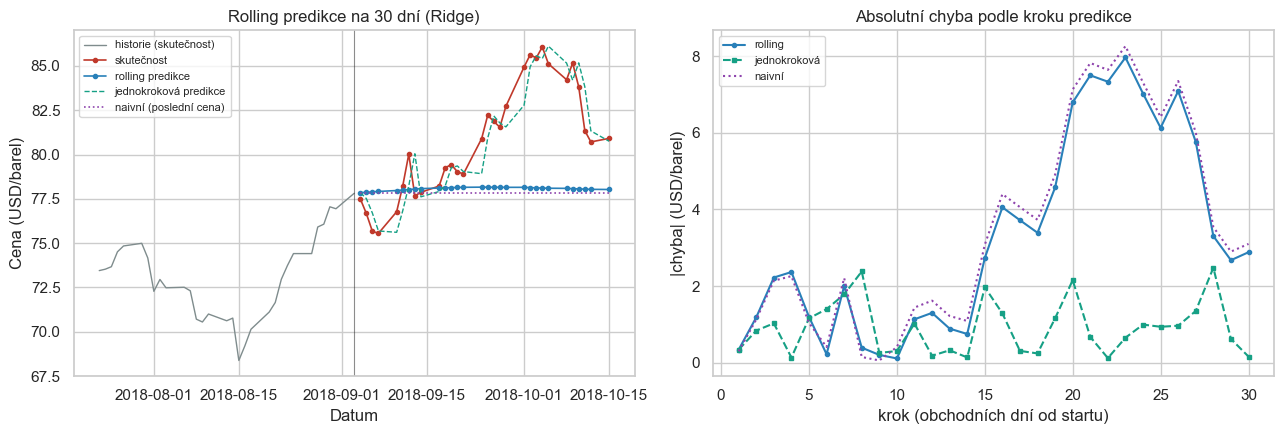

,skutečnost,rolling,chyba rolling,chyba naivní
datum,,,,
2018-09-04,77.5100,77.8512,0.3412,0.3000
2018-09-10,76.7700,77.9666,1.1966,1.0400
2018-09-17,78.2200,78.1079,-0.1121,-0.4100
2018-10-01,84.9400,78.1485,-6.7915,-7.1300
2018-10-15,80.9100,78.0265,-2.8835,-3.1000


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

context = df.iloc[rolling_start_pos - 30:rolling_start_pos + 1]
axes[0].plot(context["Date"], context["Price"], color="#7f8c8d", lw=1, label="historie (skutečnost)")
axes[0].plot(roll_dates, roll_actual, "o-", ms=3, lw=1.2, color="#c0392b", label="skutečnost")
axes[0].plot(roll_dates, roll_pred, "o-", ms=3, lw=1.2, color="#2980b9", label="rolling predikce")
axes[0].plot(roll_dates, onestep_pred, "--", lw=1, color="#16a085", label="jednokroková predikce")
axes[0].plot(roll_dates, naive_pred, ":", lw=1.2, color="#8e44ad", label="naivní (poslední cena)")
axes[0].axvline(rolling_start_date, color="k", lw=0.8, alpha=0.5)
axes[0].set_title(f"Rolling predikce na {ROLLING_HORIZON} dní (Ridge)")
axes[0].set_xlabel("Datum"); axes[0].set_ylabel("Cena (USD/barel)")
axes[0].legend(fontsize=8)

steps = np.arange(1, ROLLING_HORIZON + 1)
axes[1].plot(steps, np.abs(roll_actual - roll_pred), "o-", ms=3, color="#2980b9", label="rolling")
axes[1].plot(steps, np.abs(roll_actual - onestep_pred), "s--", ms=3, color="#16a085", label="jednokroková")
axes[1].plot(steps, np.abs(roll_actual - naive_pred), ":", color="#8e44ad", label="naivní")
axes[1].set_title("Absolutní chyba podle kroku predikce")
axes[1].set_xlabel("krok (obchodních dní od startu)"); axes[1].set_ylabel("|chyba| (USD/barel)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

rolling_detail = pd.DataFrame({
    "datum": pd.to_datetime(roll_dates).date,
    "skutečnost": roll_actual,
    "rolling": roll_pred,
    "chyba rolling": roll_pred - roll_actual,
    "chyba naivní": naive_pred - roll_actual,
}).set_index("datum")
rolling_detail.iloc[[0, 4, 9, 19, 29]]

Jeden úsek by mohl být náhoda, tak jsem stejný pokus zopakoval z několika různých
startovních dnů rozprostřených po testovacím období.


In [29]:
rolling_windows = []
for start_pos in np.linspace(rolling_start_pos, len(df) - ROLLING_HORIZON - 1, 6).astype(int):
    dates_w, actual_w, pred_w = rolling_forecast(rolling_model, start_pos)
    feature_pos = int(features.index[features["Date"] == df["Date"].iloc[start_pos]][0])
    onestep_w = rolling_model.predict(X.iloc[feature_pos:feature_pos + ROLLING_HORIZON])
    naive_w = np.repeat(df["Price"].iloc[start_pos], ROLLING_HORIZON)
    rolling_windows.append({"start": df["Date"].iloc[start_pos].date(),
                            "RMSE rolling": rmse(actual_w, pred_w),
                            "RMSE jednokroková": rmse(actual_w, onestep_w),
                            "RMSE naivní": rmse(actual_w, naive_w)})

rolling_windows_df = pd.DataFrame(rolling_windows).set_index("start")
print(rolling_windows_df.mean().to_string())
rolling_windows_df

RMSE rolling        10.8044
RMSE jednokroková    1.8614
RMSE naivní         10.7210


,RMSE rolling,RMSE jednokroková,RMSE naivní
start,,,
2018-09-03,4.1170,1.1428,4.3279
2020-03-13,11.9659,3.0409,12.6417
2021-09-28,5.1392,1.1730,5.1390
2023-04-14,11.0171,1.8139,10.1440
2024-10-29,3.9981,1.0219,3.2638
2026-05-19,28.5896,2.9759,28.8094


### Interpretace rolling predikce

Rolling predikce je v podstatě plochá. Prvních pár kroků ještě drží, pak se křivka
odlepí a zbytek měsíce se drží kolem 78 USD, zatímco skutečná cena vyskočila na
84,94 USD. RMSE proto vychází stejně jako u naivní baseline (4,12 vs. 4,33 na prvním
úseku, průměrně 10,80 vs. 10,72 přes všech šest startů) — rozdíl je v řádu šumu.
Jednokroková predikce, tedy stejný model, který ale před každým krokem dostane
skutečnou včerejší cenu, má RMSE 1,14 na prvním úseku a 1,86 v průměru, tedy zhruba
čtyřikrát až šestkrát méně.

Důvod je ten, že nejsilnější příznak je aktuální cena. Jakmile ji nahradí vlastní
odhad, výnosy z predikovaných cen jsou skoro nulové a klouzavé průměry se dotáhnou
k poslední hodnotě, takže se model nemá čeho chytit a jede vodorovně. Vnější šoky,
které cenou ropy reálně hýbou, navíc z vlastní historie vidět nejsou, proto RMSE
na úseku od 19. 5. 2026 vyletí na 28,6 USD.

Vysoké $R^2$ z části 4 tedy neznamená, že model umí předpovědět vývoj ceny, jen že
umí přesně opsat poslední známou cenu. Použitelný je jako jednokrokový model
aktualizovaný každý den skutečnými daty, ne jako predikce na měsíc dopředu.


## 7. Závěr

**Regrese.** Modely dosahují velmi vysokého $R^2$ (skoro 1) a nízké RMSE, ale
jak je zmíněno výše, je to hlavně zásluha perzistence řady. Naivní baseline
"zítra = dnes" je hodně silná a vše ostatní ji poráží jen o kousek.
Nejlépe dopadly regularizované lineární modely (Ridge a Lasso), což sedí na to,
jak jsou cenové příznaky pokorelované. Dominantní příznak je aktuální cena a
její nejbližší zpoždění.

**Klasifikace.** Přesnost je jen o něco nad hranicí
majoritní třídy (kolem 50 %), to odpovídá tomu, že denní směr ceny ropy se z
historie ceny samotné dá odhadovat velmi obtížně. Na cenu ropy má velký vliv zejména makroekonomická a politická situace ve světě a další faktory. Nejlepší modely (boosting a laděná
logistická regrese) přinesly malé, ale konzistentní zlepšení proti baseline.

**Rolling predikce.** Když modelu vezmu skutečné ceny a nechám ho 30 dní jet
jen po vlastních predikcích (část 6.6), jeho výhoda proti naivní baseline se
vytratí — predikovaná křivka se po pár dnech odlepí od skutečnosti a dál jde
skoro rovně. Přesnost z jednodenní úlohy se tedy nedá přenést na delší horizont.

**Shrnutí** Cenu příštího dne odhadne dobře i naivní model „zítra = dnes", směr pohybu nepředpoví spolehlivě ani jeden.

**Co by se dalo udělat lépe.** Využil jsem pouze cenu ropy a žádné jiné ukazatele. Nabízí se přidat
externí data (kurz dolaru, akcie energetických firem, stavy zásob, makroukazatele)
nebo sáhnout po modelech určených přímo na časové řady, jako je ARIMA nebo LSTM.
To ale není předmětem této práce. I tak si myslím, že se mi podařilo vytvořit celou pipeline od získání dat, jejich modifikaci, trénování modelů s různými parametry až po vyhodnocení pro regresi i klasifikaci.
